## Task 3: Transformed Random Variables
$\xi_{9} = 2$

$\xi_{10}=4, 123, 255, 37, 28$
 
Since $\xi_9 = 2$, the single router failure bandwidth $S$ is modeled by a probability density function (PDF): $$ f_S(s) = \frac{1}{120\theta^7} s^6 e^{-s/\theta} \quad \text{} $$

Total failure bandwidth $T$ is for two sequential routers ($S_1, S_2$).

The sample size is $N=5$.

In [25]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma 

**Step 1:**

Express $T$ and Assumptions:

Express $T$ as $T = S_1 + S_2$. Assume $S_1$ and $S_2$ are independent and identically distributed (i.i.d.)

Model Definition and Assumptions

Model Recognition (Gamma Distribution):

The density function $f_S(s)$ is recognized as the general form of a Gamma distribution $\Gamma(k, \theta)$ <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 26)</cite>: $$ f_X(x) = \frac{1}{\Gamma(k)\theta^k} x^{k-1} e^{-x/\theta} $$ Since $120 = 6! = \Gamma(7)$, the individual router bandwidth is distributed as: $$ S \sim \mathbf{\Gamma(k=7, \theta)} \quad \text{} $$

Express $T$ and Formulate Assumptions
$T$ is the total failure bandwidth for two sequential routers ($S_1$ and $S_2$). Because the failures occur sequentially, the total bandwidth is the sum: $$ \mathbf{T = S_1 + S_2} \quad \text{} $$

Realistic Assumptions: We assume that the two routers are identical and fail independently.
1.	Independent: The failure of $S_1$ does not affect the distribution of $S_2$.
2.	Identically Distributed (i.i.d.): $S_1$ and $S_2$ follow the same $\Gamma(7, \theta)$ distribution.


In [26]:
# Input Sample Data (xi_10)
T_sample = np.array([4, 123, 255, 37, 28])
N = len(T_sample)

# 1.1 Model Recognition: Gamma Distribution
# Since the PDF is proportional to s^(k-1) * exp(-s/theta), and s^6 is observed, k_single = 7
k_single = 7

# 1.2 Transformed Variable T = S1 + S2
# The sum of two Gamma distributions (with the same scale theta) results in a Gamma
# distribution where shape parameters add up.
k_total = k_single + k_single  

print(f"Shape parameter for single router (S): k_single = {k_single}")
print(f"Shape parameter for dual system (T): k_total = {k_total}")


Shape parameter for single router (S): k_single = 7
Shape parameter for dual system (T): k_total = 14


**Step 2:**

Recognizing $f_S(s)$ as $\Gamma(k=7, \theta)$ and calculating $f_T(t)$ of the sum $T$. Since $S_1, S_2$ are i.i.d. Gamma, $T \sim \Gamma(14, \theta)$

We use the properties of Transformed Random Variables <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 89)</cite>. When two independent Gamma random variables share the same scale parameter $\theta$, their sum is also a Gamma distribution, with the shape parameters added <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 81)</cite>.

$$ T \sim \Gamma(k_1 + k_2, \theta) = \Gamma(7 + 7, \theta) = \mathbf{\Gamma(14, \theta)} $$

The density function $f_T(t)$ for $T$ (where $\Gamma(14) = 13!$) is: $$ \mathbf{f_T(t) = \frac{1}{13!\theta^{14}} t^{13} e^{-t/\theta}} $$


**Step 3:**

Calculating the likelihood function $\mathcal{L}(\theta) = \prod_{i=1}^{5} f_T(T_i; \theta)$ using sample $\xi_{10}$

The likelihood function is the joint density of the observed sample $T = {T_1, \ldots, T_5}$, assuming the observations are independent and identically distributed (i.i.d.) [309, 310, Eqn 6.6]: $$ \mathcal{L}(\theta) = \prod_{i=1}^{N} f_T(T_i; \theta) $$
First, calculate the sum of the sample data, $\sum T_i$: $$ \sum_{i=1}^{5} T_i = 4 + 123 + 255 + 37 + 28 = \mathbf{447} $$
The likelihood function is: $$ \mathcal{L}(\theta) = \prod_{i=1}^{5} \left( \frac{1}{13!\theta^{14}} T_i^{13} e^{-T_i/\theta} \right) $$
We group the terms that do not depend on $\theta$ (the Constant $C_1$) and the terms that do: $$ \mathcal{L}(\theta) = \left( \frac{1}{(13!)^5} \prod_{i=1}^{5} T_i^{13} \right) \cdot \left( \theta^{-14 \cdot 5} \right) \cdot \left( e^{-\sum T_i / \theta} \right) $$ $$ \mathbf{\mathcal{L}(\theta) = C_1 \cdot \theta^{-70} e^{-447/\theta}} \quad $$
<cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 150, Eqn 6.3)</cite>


In [27]:
# Calculate the Likelihood Function L(theta) 

sum_T = np.sum(T_sample)
N_obs = N

# The exponent for theta is -(N * k_total)
N_k_total = N_obs * k_total  # 5 * 14 = 70

print(f"Sample sum (ΣT_i) = {sum_T}")
print(f"Combined shape factor (N * k_total) = {N_k_total}")

# The Likelihood function is proportional to:
# L(theta) ∝ theta^(-70) * exp(-447 / theta)
def core_likelihood(theta):
    """Calculates the Likelihood function L(theta) without constant factors."""
    if np.any(theta <= 0):
        return 0.0
    # L(theta) ∝ theta^(-N_k_total) * exp(-Sum_T / theta)
    return (theta ** (-N_k_total)) * np.exp(-sum_T / theta)

L_example_4 = core_likelihood(4.0)
print(f"Core Likelihood evaluated at theta=4 (proportional): {L_example_4:.2e}")


Sample sum (ΣT_i) = 447
Combined shape factor (N * k_total) = 70
Core Likelihood evaluated at theta=4 (proportional): 2.11e-91


**Step 4:**

Estimate $\theta_{MLE}$

Finding the Maximum Likelihood Estimate (MLE) by calculating $\ell'(\theta)$, setting it to zero, and solving for $\theta$

The likelihood function involves products and complex exponents, making direct differentiation difficult.

Proposed Transformation: We propose using the Log-Likelihood function, $\ell(\theta) = \ln(\mathcal{L}(\theta))$ <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 151, Eqn 6.7)</cite>. $$ \ell(\theta) = \ln\left( C_1 \cdot \theta^{-70} e^{-447/\theta} \right) $$

Justification: Since the natural logarithm is a monotonic and increasing function, the parameter value $\theta$ that maximizes the original likelihood function $\mathcal{L}(\theta)$ also maximizes the transformed log-likelihood function $\ell(\theta)$. 

Furthermore, it converts the product into a sum, simplifying the differentiation required for maximization.

The Log-Likelihood Function: $$ \ell(\theta) = \ln(C_1) + \ln(\theta^{-70}) + \ln(e^{-447/\theta}) $$ $$ \mathbf{\ell(\theta) = C_2 - 70 \ln(\theta) - \frac{447}{\theta}} $$


First Derivative Calculation: $$ \frac{d\ell(\theta)}{d\theta} = \frac{d}{d\theta}\left( C_2 - 70 \ln(\theta) - 447 \theta^{-1} \right) $$ $$ \frac{d\ell(\theta)}{d\theta} = 0 - 70 \cdot \frac{1}{\theta} - 447 \cdot (-\theta^{-2}) $$ $$ \frac{d\ell(\theta)}{d\theta} = -\frac{70}{\theta} + \frac{447}{\theta^2} $$

Solving for $\theta_{MLE}$: $$ 0 = -\frac{70}{\theta} + \frac{447}{\theta^2} $$ $$ \frac{70}{\theta} = \frac{447}{\theta^2} $$ Multiplying both sides by $\theta^2$: $$ 70 \theta = 447 $$ $$ \theta_{MLE} = \frac{447}{70} $$


In [28]:
# Sample data xi_10
#T_sample = np.array([4, 123, 255, 37, 28])
N = len(T_sample)
k_total = 14  # Shape parameter for T (7 + 7)
sum_T = np.sum(T_sample)

# MLE calculation: theta_MLE = Sum(T) / (N * k_total)
theta_MLE = sum_T / (N * k_total)

# Alternatively, using the derived analytical result:
# theta_MLE = 447 / 70

print(f"Sum of sample (ΣT_i): {sum_T}")
print(f"Maximum Likelihood Estimate (θ_MLE): {theta_MLE} ≈ {theta_MLE:.4f}")

# Propose and Justify Transformation (Log-Likelihood)

# Core Log-Likelihood Function (vectorized to handle array input correctly)
# We ensure theta > 0, as required for the Gamma distribution scale parameter.
def core_log_likelihood(theta):
    """
    Calculates the core log-likelihood function: l(theta) = - N*k * ln(theta) - Sum(T_i) / theta.
    Returns -inf for non-positive theta.
    """

    # Define parameters within the function scope or rely on global scope
    N_k_total = 70
    Sum_T = 447

    # Core mathematical calculation (This is vectorizable)
    result = -N_k_total * np.log(theta) - Sum_T / theta

    # Use np.where to enforce the domain constraint (theta > 0)
    return np.where(theta > 0, result, -np.inf)

ll_example_4 = core_log_likelihood(4.0)
print(f"Core Log-Likelihood evaluated at theta=4: {ll_example_4:.4f}")


Sum of sample (ΣT_i): 447
Maximum Likelihood Estimate (θ_MLE): 6.385714285714286 ≈ 6.3857
Core Log-Likelihood evaluated at theta=4: -208.7906


**Step 5:**

Compute $E[T]$

Compute the expectation $E[T] = k\theta$ using the estimated $\theta_{MLE}$

In [29]:
# Sample data xi_10
N = len(T_sample)
k_total = 14  # Shape parameter for T (7 + 7)
sum_T = np.sum(T_sample)

# MLE calculation: theta_MLE = Sum(T) / (N * k_total)
theta_MLE = sum_T / (N * k_total)

# Alternatively, using the derived analytical result:
# theta_MLE = 447 / 70

print(f"Sum of sample (ΣT_i): {sum_T}")
print(f"Maximum Likelihood Estimate (θ_MLE): {theta_MLE} ≈ {theta_MLE:.4f}")


Sum of sample (ΣT_i): 447
Maximum Likelihood Estimate (θ_MLE): 6.385714285714286 ≈ 6.3857


**Step 6**

Computing the Expectation of the Dual-Router-System ($E[T]$)

The dual-router-system bandwidth $T$ follows the distribution $\Gamma(14, \theta)$. The expectation value for a Gamma distribution is $E[T] = k \theta$.

We use the estimated parameter $\theta_{MLE}$: $$ E[T] = k_{total} \cdot \theta_{MLE} $$ $$ E[T] = 14 \cdot \frac{447}{70} $$ $$ E[T] = \frac{14}{70} \cdot 447 = \frac{1}{5} \cdot 447 = \mathbf{89.4} $$


In [30]:
# Expectation calculation
E_T = k_total * theta_MLE

print(f"Expectation of the dual-router-system E[T]: {E_T:.1f} terabytes")

Expectation of the dual-router-system E[T]: 89.4 terabytes


**Visualization 1: Fitted PDF and Sample Data**

We plot the derived probability density function $f_T(t)$ for the total bandwidth $T$ using the estimated parameter $\theta_{MLE}$.

$$ f_T(t) \sim \Gamma(k=14, \theta_{MLE}=6.3857) $$

This plot (a visualization technique for continuous distributions <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 116)</cite>) will demonstrate the likelihood of observing various total bandwidth values and locate the calculated mean $E[T]$ relative to the distribution's peak.


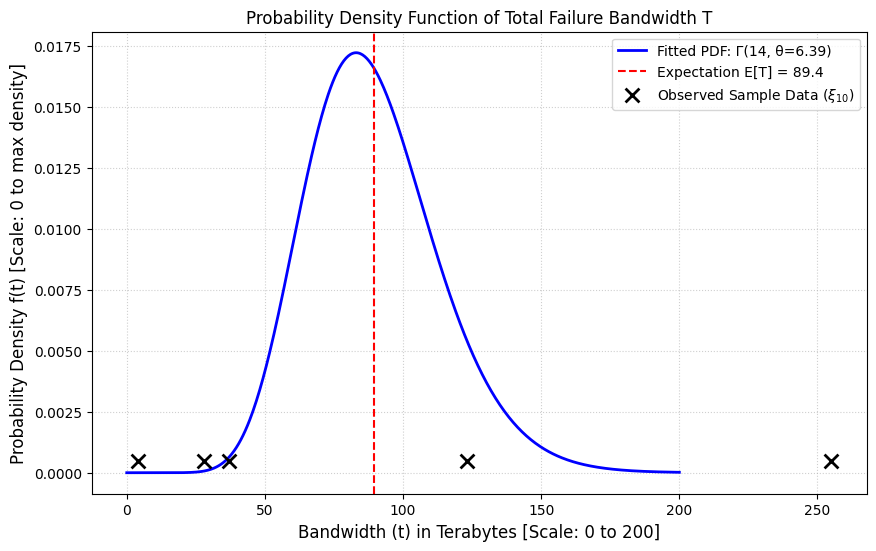

In [31]:
# Parameters calculated from Task 3 steps
k_total = 14
theta_MLE = 447 / 70  # 6.3857
E_T = k_total * theta_MLE  # 89.4
#T_sample = np.array([4, 123, 255, 37, 28])  # Sample xi_10

# --- Plotting the PDF ---

# Define a range for t (bandwidth, in terabytes). We go up to 200, as E[T] is 89.4
t_values = np.linspace(0, 200, 500)

# Calculate PDF: Note that scipy parameterizes Gamma with (a, scale) where a=k and scale=theta.
pdf_values = gamma.pdf(t_values, a=k_total, scale=theta_MLE)

plt.figure(figsize=(10, 6))

# Plot the calculated Probability Density Function (PDF)
plt.plot(t_values, pdf_values, color='blue', linewidth=2,
         label=f'Fitted PDF: Γ({k_total}, θ={theta_MLE:.2f})')

# Mark the Expected Value E[T]
plt.axvline(E_T, color='red', linestyle='--',
            label=f'Expectation E[T] = {E_T:.1f}')

# Plot the observed sample data (as a rug plot/scatter)
# We use a small y-offset so the points are visible above the axis
y_sample_offset = 0.0005
plt.scatter(T_sample, [y_sample_offset] * len(T_sample),
            color='black', marker='x', s=100, linewidths=2, zorder=5,
            label='Observed Sample Data ($\\xi_{10}$)')

# Formatting (Required: Include Scale/Labels)
plt.title('Probability Density Function of Total Failure Bandwidth T')
plt.xlabel('Bandwidth (t) in Terabytes [Scale: 0 to 200]', fontsize=12)
plt.ylabel('Probability Density f(t) [Scale: 0 to max density]', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


**Visualization 2: Log-Likelihood Function $\ell(\theta)$**

The log-likelihood function derived in Task 3 was: $$ \mathbf{\ell(\theta) = C_2 - 70 \ln(\theta) - \frac{447}{\theta}} $$ We plot this function over a range of $\theta$ values to visually demonstrate that the calculated $\theta_{MLE} \approx 6.3857$ maximizes the function <cite data-cite="con:coursebook"> (Advanced Statistics DLMDSAS01, 2025, p. 152)</cite>.

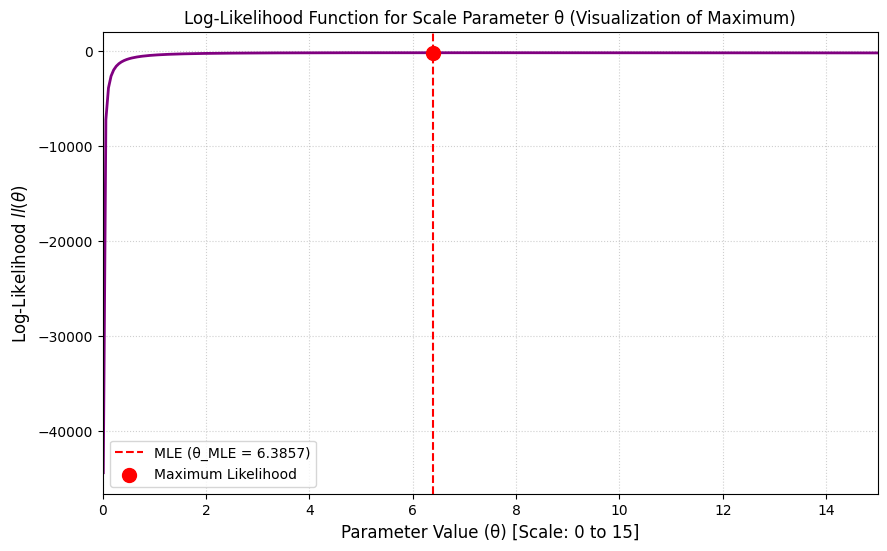

In [32]:
# Parameters calculated from Task 3 steps (re-verification)
N_k = 70      # N * k_total = 5 * 14
Sum_T = 447   # Sum(T_i) from xi_10 = {4, 123, 255, 37, 28} [1]
theta_MLE = Sum_T / N_k

# --- CORRECTED Log-Likelihood Function using np.where for vectorization ---
def log_likelihood(theta):
    """
    Calculates the log-likelihood function: l(theta) = - 70 * ln(theta) - 447 / theta
    Handles non-positive theta values by returning -infinity.
    """
    
    # Core mathematical calculation (This is vectorizable)
    # We must ensure np.log(theta) is only evaluated for theta > 0, 
    # but NumPy handles log of small positive numbers without explicit check here 
    # if we use np.where for the final output.
    
    # Calculate the expression result (NumPy handles division by zero/log errors gracefully
    # by generating warnings/NaNs, which we then overwrite with np.where)
    result = -N_k * np.log(theta) - Sum_T / theta
    
    # Use np.where to enforce the domain constraint (theta > 0)
    # The Log-likelihood requires theta > 0 for the Gamma distribution [U3: Table 3, P. 26].
    return np.where(theta > 0, result, -np.inf)

# --- Visualization 2: Log-Likelihood Plot ---

# Define a range for theta. We start at a strictly positive value (e.g., 0.01) to 
# capture the behavior leading up to the maximum, but plotting starts at 1 for clearer visibility
theta_values = np.linspace(0.01, 15, 300) 

# Re-run the function call with the array input:
ll_values = log_likelihood(theta_values) 

plt.figure(figsize=(10, 6))

# Plot the Log-Likelihood function [U6: 6.1, P. 152]
plt.plot(theta_values, ll_values, color='purple', linewidth=2)

# Mark the Maximum Likelihood Estimate
ll_max = log_likelihood(theta_MLE)
plt.axvline(theta_MLE, color='red', linestyle='--', 
            label=f'MLE (θ_MLE = {theta_MLE:.4f})')
plt.scatter(theta_MLE, ll_max, color='red', s=100, zorder=5, 
            label='Maximum Likelihood')

# Formatting 
plt.title('Log-Likelihood Function for Scale Parameter θ (Visualization of Maximum)')
plt.xlabel('Parameter Value (θ) [Scale: 0 to 15]', fontsize=12)
plt.ylabel('Log-Likelihood $ll(\\theta)$', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 15)
plt.show()

**Analogy:** 

Determining the density function of the total bandwidth $T$ is like finding the probability distribution for the time taken to complete a complex assembly task, where the total time is the sum of two identical, independent sub-tasks (S1 and S2). Because the sub-tasks are similar and independent, the complexity (shape parameter) of the overall task adds up, resulting in a predictable overall process, described by the new Gamma distribution. The MLE finds the single best "scale factor" ($\theta$) that makes the model fit the observed failure times perfectly.